In [4]:
# Script para gerar tabelas de contagem por família e por elemento a partir do resultado do BedTools.

#####################################################################################################################################################
#!/usr/bin/env python3
import sys
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# ── Caminhos: edite aqui se necessário ───────────────────────────────────────
# Modo terminal:  python3 count_TEs.py INPUT OUT_FAM OUT_ELE
# Modo Jupyter:   edite as variáveis DEFAULT_ abaixo
DEFAULT_INPUT   = "/mnt/d/Mestrado/Phylogenetic_analysis/BedTools.xlsx"
DEFAULT_OUT_FAM = "/mnt/d/Mestrado/Phylogenetic_analysis/count_family.xlsx"
DEFAULT_OUT_ELE = "/mnt/d/Mestrado/Phylogenetic_analysis/count_element.xlsx"

def _arg(n, default):
    try:
        val = sys.argv[n]
        return val if not val.startswith("-") else default
    except IndexError:
        return default

INPUT   = _arg(1, DEFAULT_INPUT)
OUT_FAM = _arg(2, DEFAULT_OUT_FAM)
OUT_ELE = _arg(3, DEFAULT_OUT_ELE)

# ── Leitura ──────────────────────────────────────────────────────────────────
df = pd.read_excel(INPUT, sheet_name="bedtools")
df["host"] = df["host"].ffill()

HOSTS = ["Fish", "Human", "Bovine"]

# ── Normalização case-insensitive ─────────────────────────────────────────────
def normalize_col(series):
    """
    Agrupa entradas que diferem apenas em maiúsculas/minúsculas ou espaços.
    Mantém o nome canônico = primeira ocorrência (ordem do arquivo).
    Ex: 'Compound transposon' e 'Compound Transposon' → mesmo grupo,
    nome exibido = o que aparecer primeiro.
    """
    key = series.str.strip().str.lower()           # chave de agrupamento
    # mapa lowercase → primeira ocorrência (nome canônico)
    canonical = (
        pd.DataFrame({"orig": series, "key": key})
        .dropna()
        .drop_duplicates("key", keep="first")
        .set_index("key")["orig"]
    )
    return key, canonical

# ── Helpers de formatação ─────────────────────────────────────────────────────
HEADER_FILL = PatternFill("solid", start_color="2F5496")
HEADER_FONT = Font(bold=True, color="FFFFFF", name="Arial", size=11)
CELL_FONT   = Font(name="Arial", size=10)
CENTER      = Alignment(horizontal="center", vertical="center")
LEFT        = Alignment(horizontal="left",   vertical="center")
THIN        = Side(style="thin", color="BFBFBF")
BORDER      = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)

def style_sheet(ws, col_headers):
    for col_idx, header in enumerate(col_headers, start=1):
        cell = ws.cell(row=1, column=col_idx, value=header)
        cell.font = HEADER_FONT; cell.fill = HEADER_FILL
        cell.alignment = CENTER; cell.border = BORDER

def write_rows(ws, data_rows):
    ALT_FILL = PatternFill("solid", start_color="DCE6F1")
    for row_idx, row in enumerate(data_rows, start=2):
        fill = ALT_FILL if row_idx % 2 == 0 else None
        for col_idx, val in enumerate(row, start=1):
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.font = CELL_FONT; cell.border = BORDER
            cell.alignment = LEFT if col_idx == 1 else CENTER
            if fill: cell.fill = fill

def set_col_widths(ws, widths):
    for col_letter, w in widths.items():
        ws.column_dimensions[col_letter].width = w

# ── 1. Contagem por FAMÍLIA ───────────────────────────────────────────────────
fam_df = df[df["family"].notna() & df["family counting"].notna()].copy()
fam_df["family counting"] = pd.to_numeric(fam_df["family counting"], errors="coerce")

fam_key, fam_canonical = normalize_col(fam_df["family"])
fam_df["family_key"] = fam_key

pivot_fam = (
    fam_df
    .groupby(["family_key", "host"])["family counting"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=HOSTS, fill_value=0)
    .reset_index()
)
pivot_fam["family"] = pivot_fam["family_key"].map(fam_canonical)
pivot_fam = (pivot_fam
    .drop(columns="family_key")
    [["family"] + HOSTS]
    .sort_values("family")
    .reset_index(drop=True)
)

wb_fam = Workbook()
ws_fam = wb_fam.active
ws_fam.title = "family_count"
ws_fam.row_dimensions[1].height = 20
style_sheet(ws_fam, ["family", "Fish", "Human", "Bovine"])
write_rows(ws_fam, pivot_fam.itertuples(index=False, name=None))
set_col_widths(ws_fam, {"A": 22, "B": 12, "C": 12, "D": 12})
wb_fam.save(OUT_FAM)
print(f"✔  Famílias → {OUT_FAM}  ({len(pivot_fam)} linhas)")

# ── 2. Contagem por ELEMENTO ──────────────────────────────────────────────────
ele_df = df[df["element"].notna() & df["elements count"].notna()].copy()
ele_df["elements count"] = pd.to_numeric(ele_df["elements count"], errors="coerce")

ele_key, ele_canonical = normalize_col(ele_df["element"])
ele_df["element_key"] = ele_key

pivot_ele = (
    ele_df
    .groupby(["element_key", "host"])["elements count"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=HOSTS, fill_value=0)
    .reset_index()
)
pivot_ele["element"] = pivot_ele["element_key"].map(ele_canonical)
pivot_ele = (pivot_ele
    .drop(columns="element_key")
    [["element"] + HOSTS]
    .sort_values("element")
    .reset_index(drop=True)
)

wb_ele = Workbook()
ws_ele = wb_ele.active
ws_ele.title = "element_count"
ws_ele.row_dimensions[1].height = 20
style_sheet(ws_ele, ["elements", "Fish", "Human", "Bovine"])
write_rows(ws_ele, pivot_ele.itertuples(index=False, name=None))
set_col_widths(ws_ele, {"A": 22, "B": 12, "C": 12, "D": 12})
wb_ele.save(OUT_ELE)
print(f"✔  Elementos → {OUT_ELE}  ({len(pivot_ele)} linhas)")
#####################################################################################################################################################

✔  Famílias → /mnt/d/Mestrado/Phylogenetic_analysis/count_family.xlsx  (20 linhas)
✔  Elementos → /mnt/d/Mestrado/Phylogenetic_analysis/count_element.xlsx  (64 linhas)


In [1]:
!micromamba install matplotlib pandas seaborn openpyxl numpy -c conda-forge -y

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache

Pinned packages:

  - python=3.14


Transaction

  Prefix: /home/vitor/.local/share/mamba/envs/General_Use

  Updating specs:

   - matplotlib
   - pandas
   - seaborn
   - openpyxl
   - numpy


  Package                        Version  Build                Channel           Size
───────────────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────────────

  + alsa-lib                    1.2.15.3  hb03c661_0           conda-forge      585kB
  + brotli                         1.2.0  hed03a55_1           conda-forge     Cached
  + brotli-bin                     1.2.0  hb03c661_1           conda-forge     Cached
  + cairo                         1.18.4  he90730b_1           conda-forge      990kB
  + contourpy                      1.3.3  

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import seaborn as sns; sns.set_theme()
import openpyxl # for reading xlsx files
import csv # for reading csv files 
import numpy as np

# Primeiro Heatmap - Heatmap das famílias de TEs encontradas

In [6]:
# Carregando os dados
## set_index('family') define a coluna 'family' como índice do DataFrame 
ALL_family = pd.read_excel(r'/mnt/d/Mestrado/Phylogenetic_analysis/count_family.xlsx', sheet_name=0).set_index('family')

print(f"Dimensões: {ALL_family.shape}")
ALL_family

Dimensões: (20, 3)


,Fish,Human,Bovine
family,,,
Compound Transposon,0,33,9
IS110,0,0,9
IS1182,22,180,387
IS1380,0,0,1
IS1595,0,5,27
IS200/IS605,0,1,12
IS21,57,61,108
IS256,0,47,258
IS3,315,384,324


In [7]:
# Aplicando a transformação log10
ALL_family_log = np.log10(ALL_family + 1)

# Visualizar os dados transformados
ALL_family_log

,Fish,Human,Bovine
family,,,
Compound Transposon,0.000000,1.531479,1.000000
IS110,0.000000,0.000000,1.000000
IS1182,1.361728,2.257679,2.588832
IS1380,0.000000,0.000000,0.301030
IS1595,0.000000,0.778151,1.447158
IS200/IS605,0.000000,0.301030,1.113943
IS21,1.763428,1.792392,2.037426
IS256,0.000000,1.681241,2.413300
IS3,2.499687,2.585461,2.511883


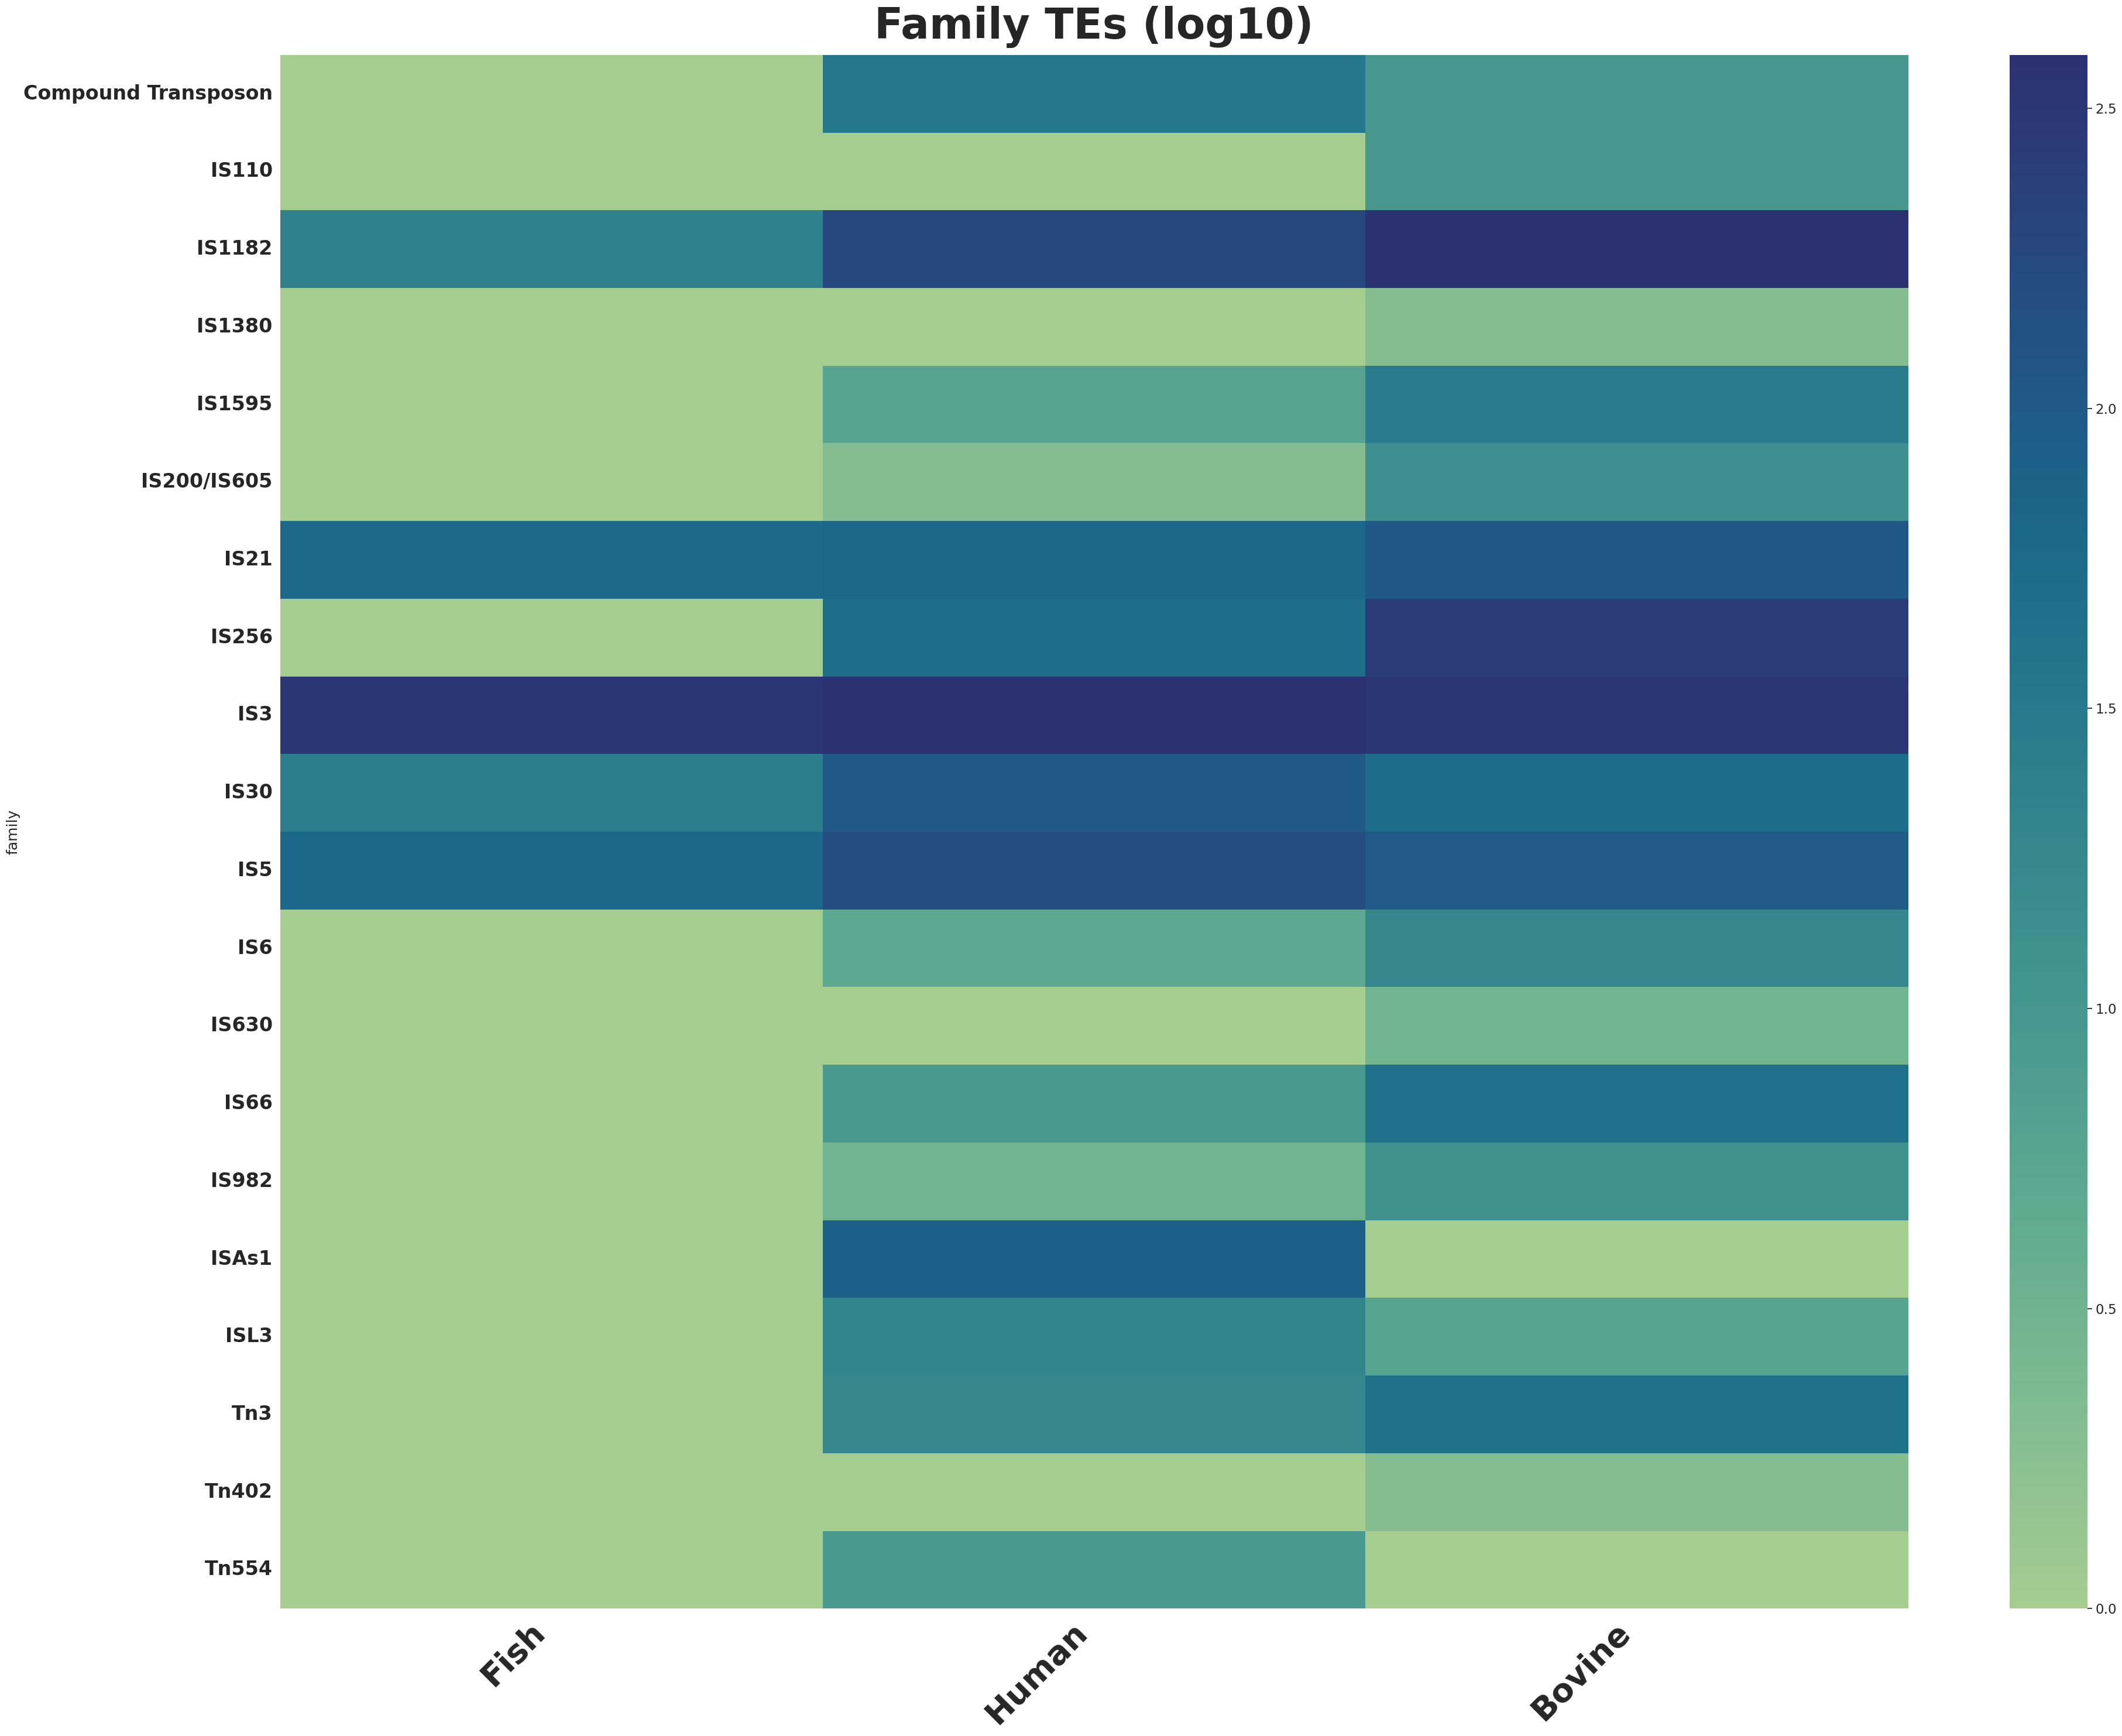

In [8]:
# Heatmap das famílias de TEs (log10)

# Configurar tamanho da figura
plt.figure(figsize=(40, 30))
sns.set(font_scale=1.5)

# Criar o heatmap com as famílias de TEs encontradas
ax = sns.heatmap(ALL_family_log, 
                 cmap="crest" # colormap 
                 )

# Configurar título da parte superior do gráfico
ax.set_title('Family TEs (log10)', 
             fontsize=52, # tamanho da fonte
             fontweight='bold', # negrito 
             pad=20 # espaçamento entre o título e o gráfico
             ) 

# Configurar rótulos do eixo Y (Famílias)
ax.set_yticklabels(ax.get_yticklabels(), # obter os rótulos atuais do eixo Y 
                   fontsize=24, # tamanho da fonte 
                   fontweight='bold', # negrito
                   fontfamily='sans-serif' # tipo de fonte
                   )

# Configurar rótulos do eixo X (Espécies)
ax.set_xticklabels(ax.get_xticklabels(), 
                   fontsize=40, 
                   fontweight='bold',
                   fontfamily='sans-serif',
                   rotation=45,
                   ha='right')

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()

# Segundo Heatmap - Heatmap dos elementos de TEs encontrados

In [9]:
# Carregando os dados
## set_index('element') define a coluna 'family' como índice do DataFrame 
ALL_elements = pd.read_excel(r'/mnt/d/Mestrado/Phylogenetic_analysis/count_element.xlsx', sheet_name=0).set_index('elements')

print(f"Dimensões: {ALL_elements.shape}")
ALL_elements

Dimensões: (64, 3)


,Fish,Human,Bovine
elements,,,
IS-LL6,0,0,2
IS1167,0,2,0
IS1167A,0,7,0
IS1194,0,0,2
IS1216E,0,5,12
...,...,...,...
Tn6246,0,2,3
Tn6674,0,8,0
Tn7114,0,1,0


In [10]:
# Aplicando a transformação log10
ALL_elements_log = np.log10(ALL_elements + 1)

# Visualizar os dados transformados
ALL_elements_log

,Fish,Human,Bovine
elements,,,
IS-LL6,0.0,0.000000,0.477121
IS1167,0.0,0.477121,0.000000
IS1167A,0.0,0.903090,0.000000
IS1194,0.0,0.000000,0.477121
IS1216E,0.0,0.778151,1.113943
...,...,...,...
Tn6246,0.0,0.477121,0.602060
Tn6674,0.0,0.954243,0.000000
Tn7114,0.0,0.301030,0.000000


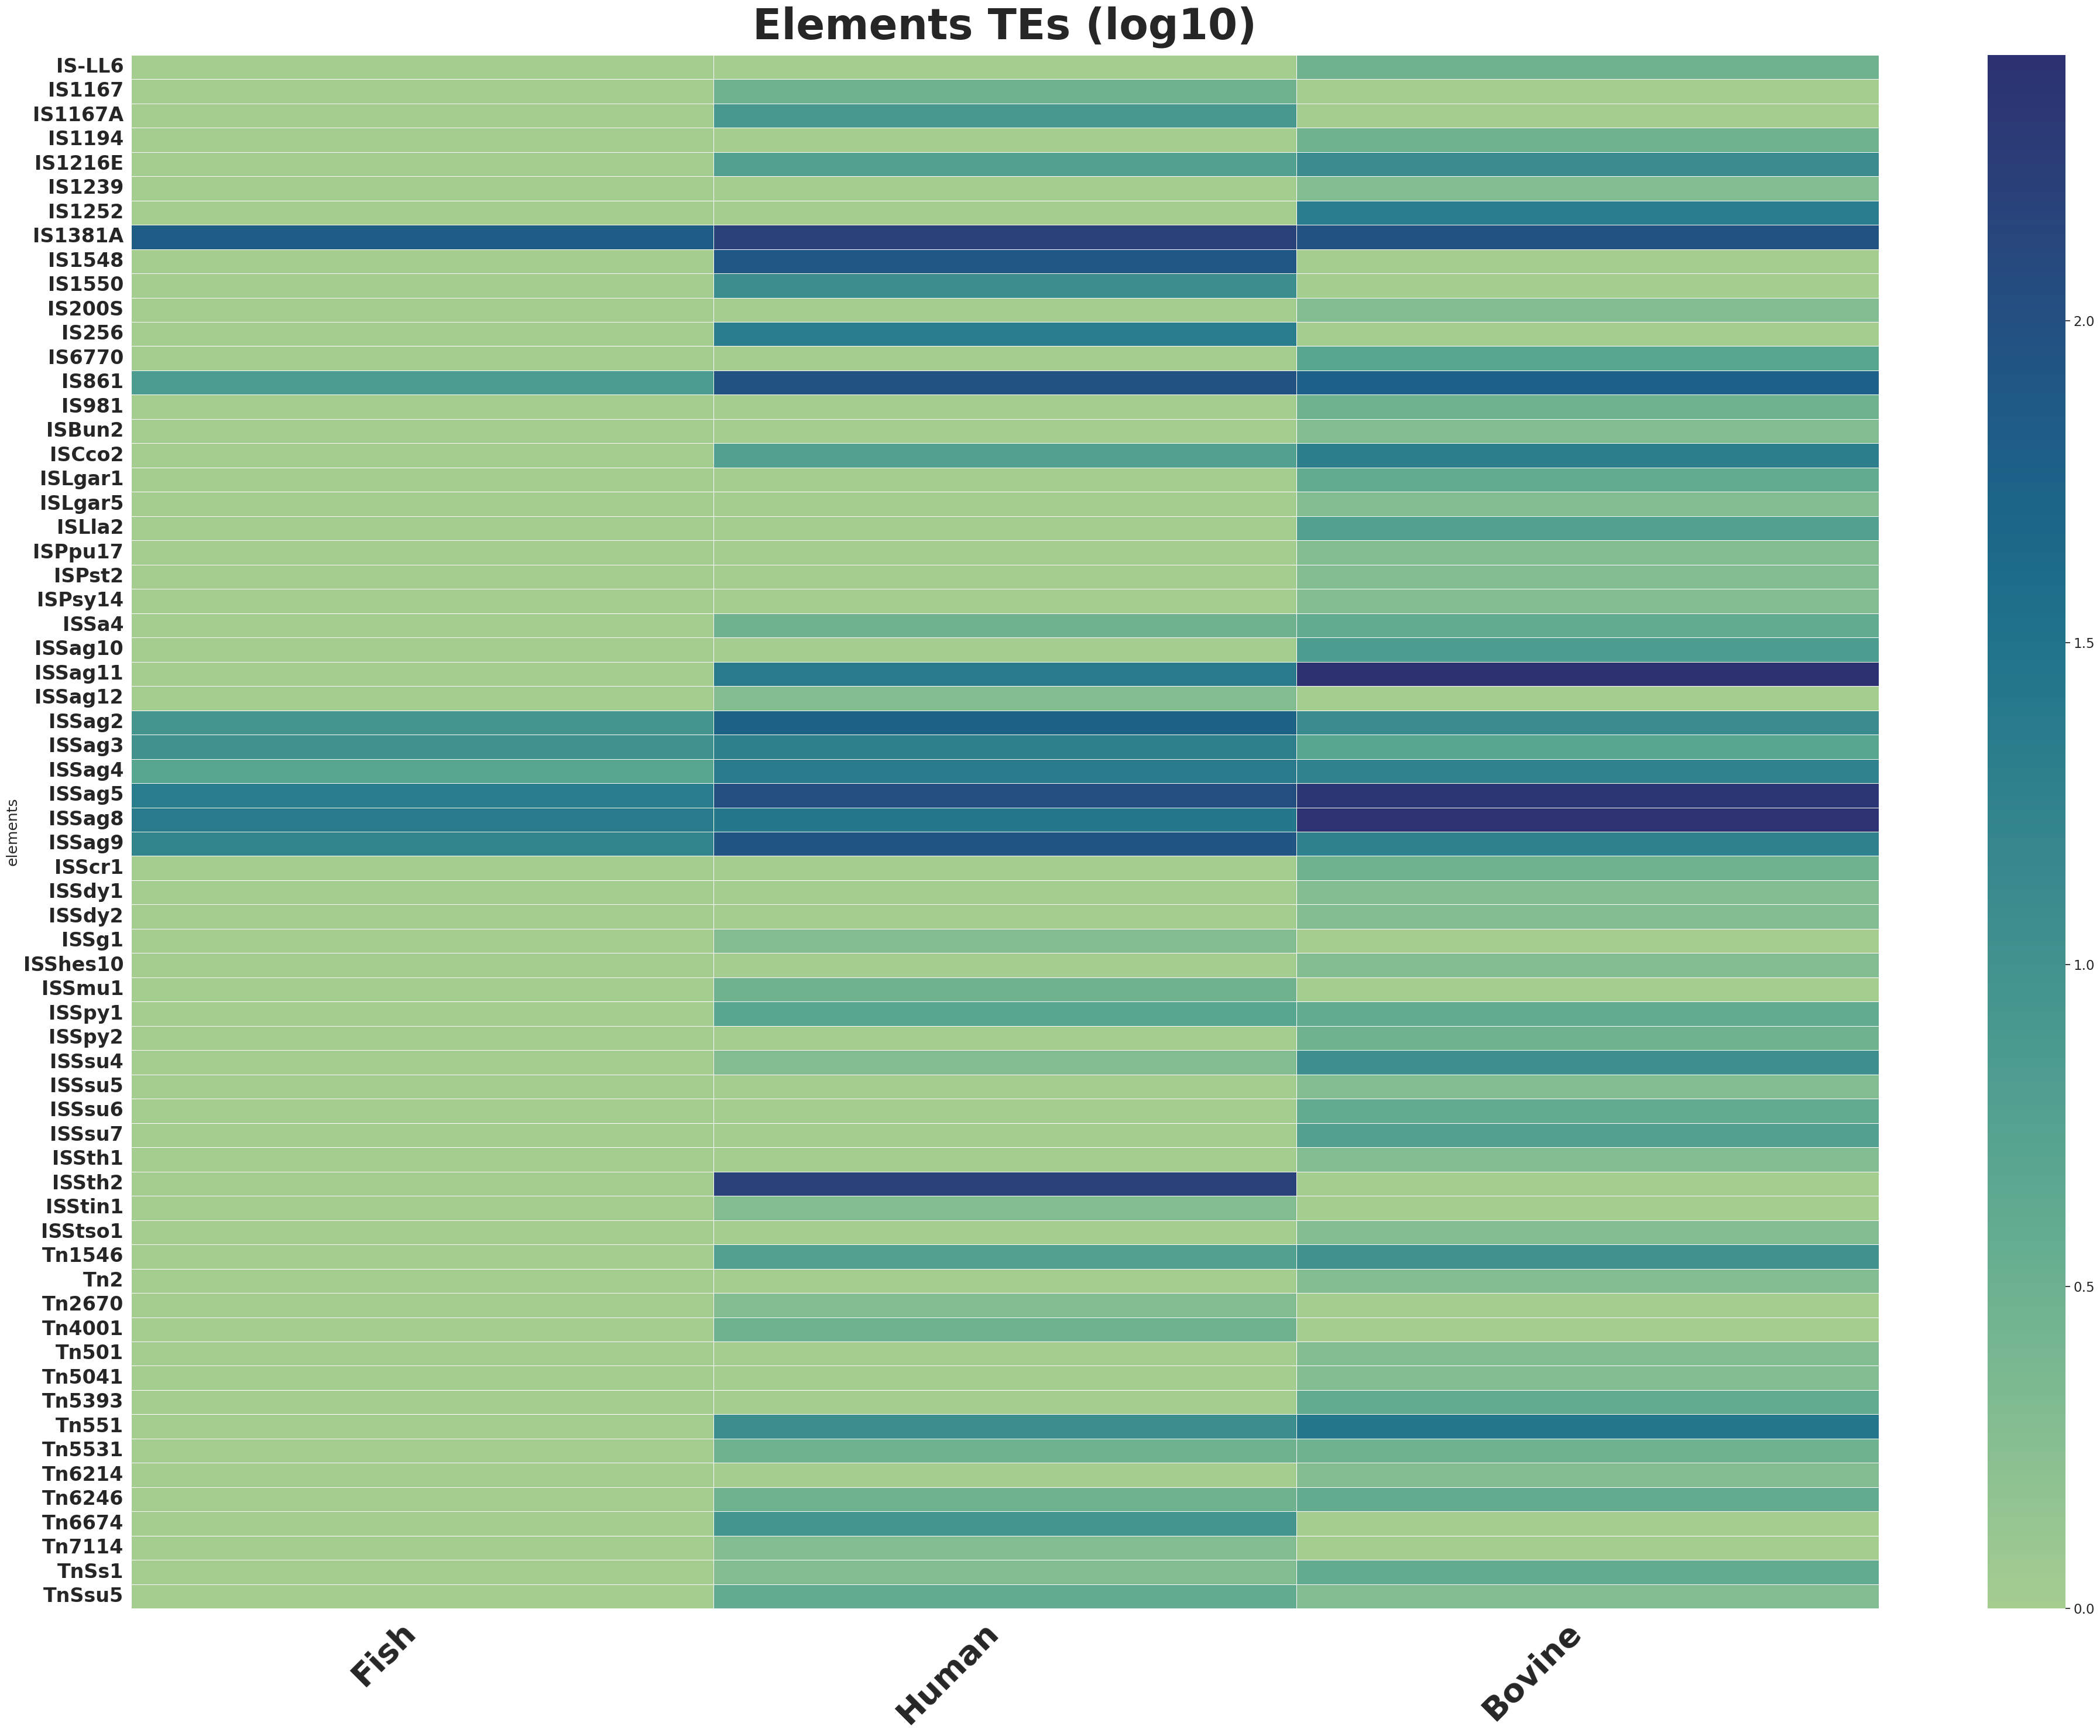

In [11]:
# Configurar tamanho da figura
plt.figure(figsize=(40, 30))
sns.set(font_scale=1.5)

# Criar o heatmap com dados dos elementos de TEs encontrados
ax = sns.heatmap(ALL_elements_log,  
                 cmap="crest", # colormap
                 linewidths=0.5, # largura das linhas entre as células 
                 linecolor='white' # cor das linhas entre as células
                 )

# Configurar título da parte superior do gráfico 
ax.set_title('Elements TEs (log10)', 
             fontsize=52, 
             fontweight='bold', # negrito
             pad=20 # espaçamento entre o título e o gráfico
             )

# Configurar rótulos do eixo Y (Elementos)
ax.set_yticklabels(ax.get_yticklabels(), 
                   fontsize=24, 
                   fontweight='bold', # negrito
                   fontfamily='sans-serif' # tipo de fonte
                   )

# Configurar rótulos do eixo X (Espécies)
ax.set_xticklabels(ax.get_xticklabels(), 
                   fontsize=40, 
                   fontweight='bold',
                   fontfamily='sans-serif',
                   rotation=45,
                   ha='right')

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()

# Unir AMBOS os Heatmaps na Mesma Imagem

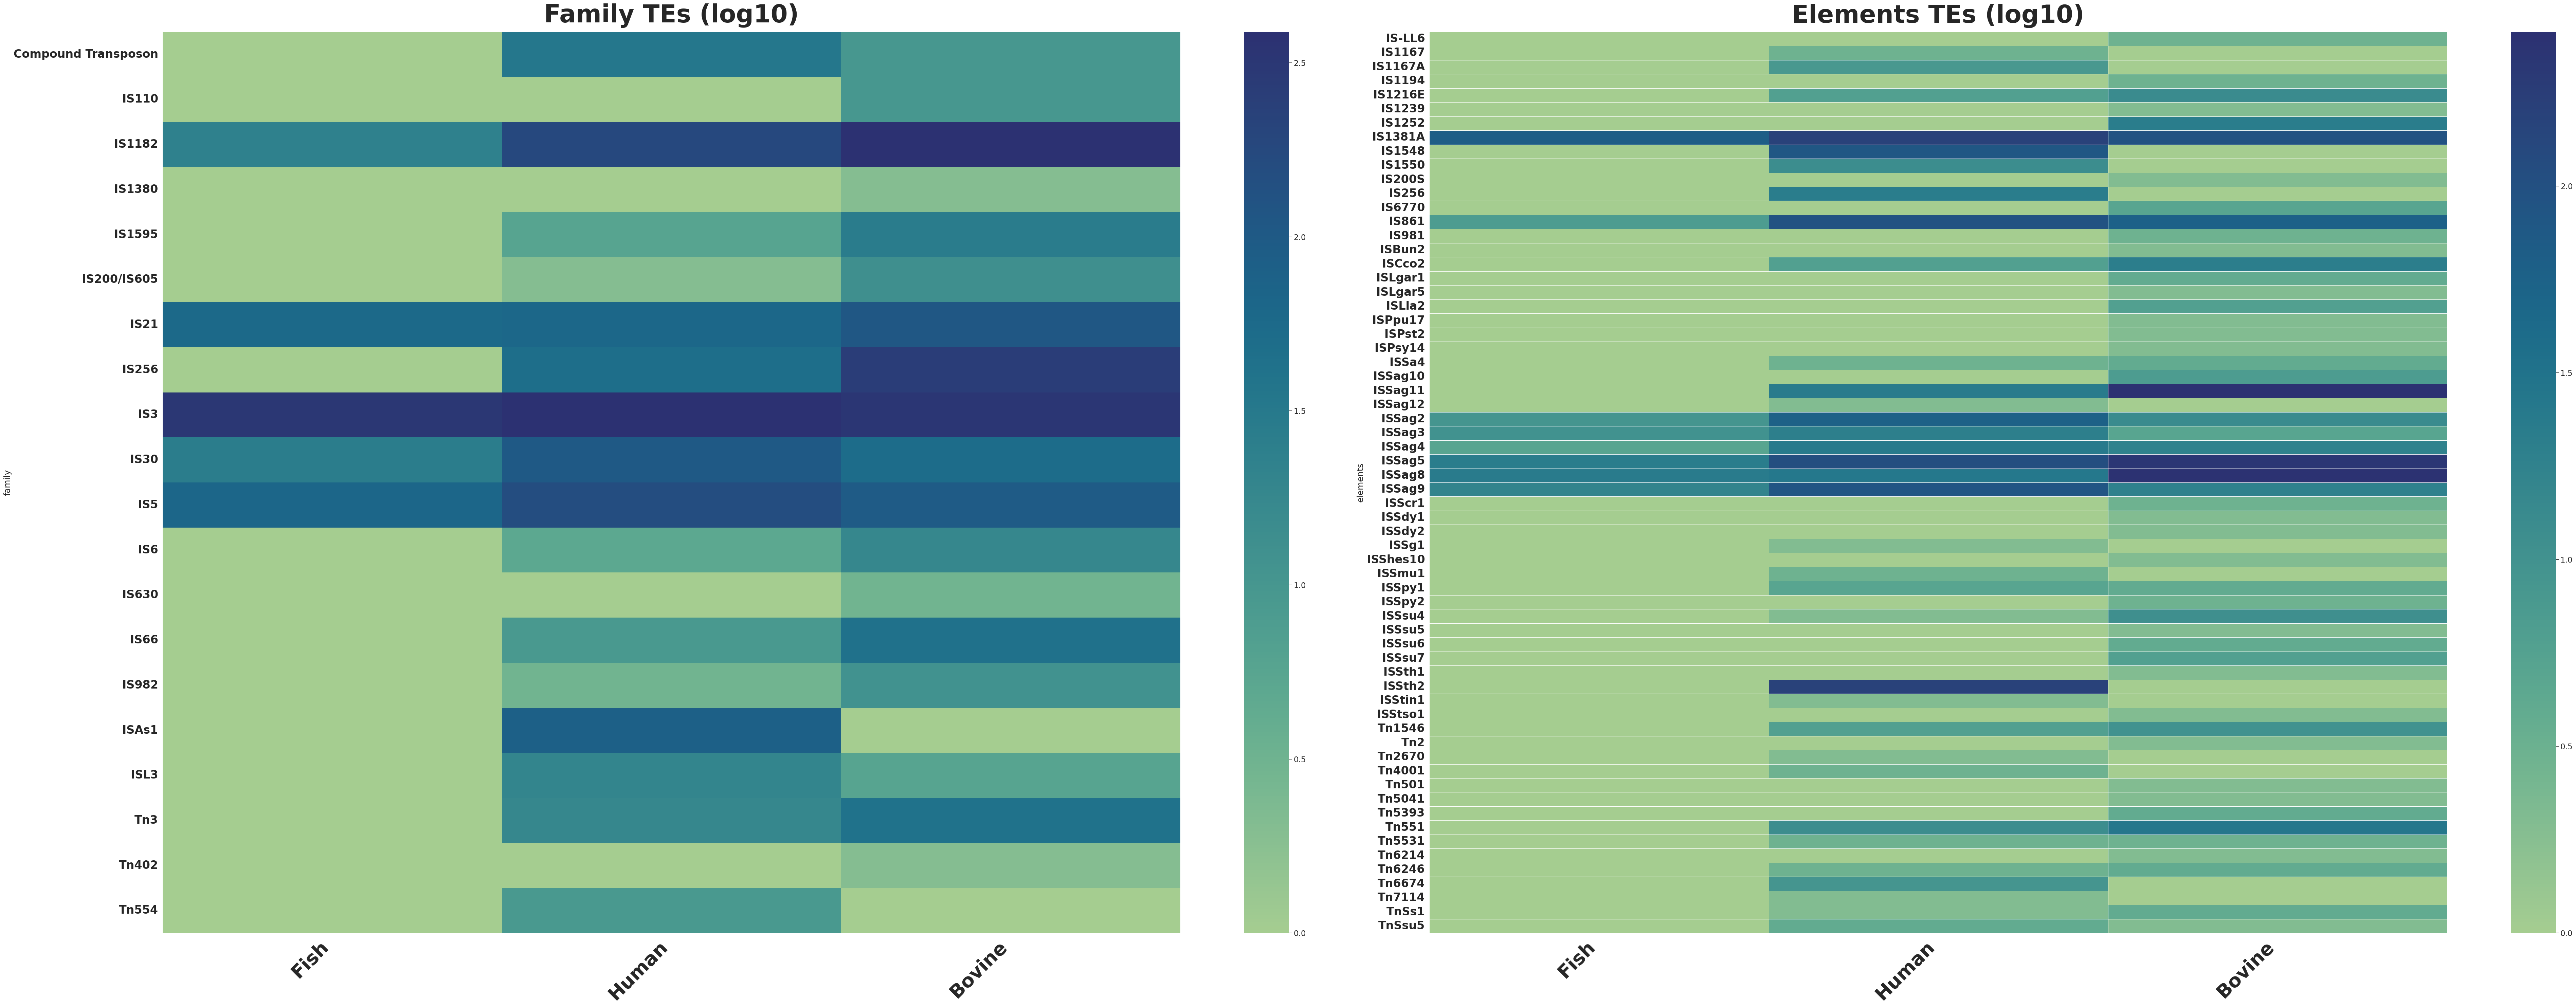

In [12]:
# Criar figura com dois subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(80, 30))

# Configurar escala da fonte
sns.set(font_scale=1.5)

# ============ HEATMAP 1: Dados das famílias de TEs ============
sns.heatmap(ALL_family_log, 
            cmap="crest", # colormap 
            ax=ax1 # definir o eixo para o primeiro subplot
                )

# Configurar título da parte superior do gráfico
ax1.set_title('Family TEs (log10)', 
             fontsize=52, # tamanho da fonte
             fontweight='bold', # negrito 
             pad=20 # espaçamento entre o título e o gráfico
             ) 

# Configurar rótulos do eixo Y (Famílias)
labels_y = ax1.get_yticklabels() 
ax1.set_yticklabels(labels_y, # obter os rótulos atuais do eixo Y 
                   fontsize=24, # tamanho da fonte 
                   fontweight='bold', # negrito
                   fontfamily='sans-serif' # tipo de fonte
                   )

# Configurar rótulos do eixo X (Espécies)
labels_x = ax1.get_xticklabels()
ax1.set_xticklabels(labels_x, 
                   fontsize=40, 
                   fontweight='bold',
                   fontfamily='sans-serif',
                   rotation=45,
                   ha='right')

# ============ HEATMAP 2: Dados dos elementos de TEs ============
sns.heatmap(ALL_elements_log,  
                 cmap="crest", # colormap
                 ax=ax2, # definir o eixo para o segundo subplot
                 linewidths=0.5, # largura das linhas entre as células 
                 linecolor='white' # cor das linhas entre as células
                 )

# Configurar título
ax2.set_title('Elements TEs (log10)', 
             fontsize=52, 
             fontweight='bold', # negrito
             pad=20 # espaçamento entre o título e o gráfico
             )

# Configurar rótulos do eixo Y (Elementos)
labels_y2 = ax2.get_yticklabels()
ax2.set_yticklabels(labels_y2, 
                   fontsize=24, 
                   fontweight='bold', # negrito
                   fontfamily='sans-serif' # tipo de fonte
                   )

# Configurar rótulos do eixo X (Espécies)
labels_x2 = ax2.get_xticklabels()
ax2.set_xticklabels(labels_x2, 
                   fontsize=40, 
                   fontweight='bold',
                   fontfamily='sans-serif',
                   rotation=45,
                   ha='right')

#####################################################################################################################################################

# Ajustar layout
plt.tight_layout()

# Mostrar os dois gráficos juntos
plt.show()

In [13]:
# Criar figura com dois subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(80, 30))

# Configurar escala da fonte
sns.set(font_scale=1.5)

# ============ HEATMAP 1: Dados das famílias de TEs ============
sns.heatmap(ALL_family_log, 
            cmap="crest", # colormap 
            ax=ax1 # definir o eixo para o primeiro subplot
                )

# Configurar título da parte superior do gráfico
ax1.set_title('Family TEs (log10)', 
             fontsize=52, # tamanho da fonte
             fontweight='bold', # negrito 
             pad=20 # espaçamento entre o título e o gráfico
             ) 

# Configurar rótulos do eixo Y (Famílias)
labels_y = ax1.get_yticklabels() 
ax1.set_yticklabels(labels_y, # obter os rótulos atuais do eixo Y 
                   fontsize=24, # tamanho da fonte 
                   fontweight='bold', # negrito
                   fontfamily='sans-serif' # tipo de fonte
                   )

# Configurar rótulos do eixo X (Espécies)
labels_x = ax1.get_xticklabels()
ax1.set_xticklabels(labels_x, 
                   fontsize=40, 
                   fontweight='bold',
                   fontfamily='sans-serif',
                   rotation=45,
                   ha='right')

# ============ HEATMAP 2: Dados dos elementos de TEs ============
sns.heatmap(ALL_elements_log,  
                 cmap="crest", # colormap
                 ax=ax2, # definir o eixo para o segundo subplot
                 linewidths=0.5, # largura das linhas entre as células
                 linecolor='white' # cor das linhas entre as células
                 )

# Configurar título
ax2.set_title('Elements TEs (log10)', 
             fontsize=52, 
             fontweight='bold', # negrito
             pad=20 # espaçamento entre o título e o gráfico
             )

# Configurar rótulos do eixo Y (Elementos)
labels_y2 = ax2.get_yticklabels()
ax2.set_yticklabels(labels_y2, 
                   fontsize=24, 
                   fontweight='bold', # negrito
                   fontfamily='sans-serif' # tipo de fonte
                   )

# Configurar rótulos do eixo X (Espécies)
labels_x2 = ax2.get_xticklabels()
ax2.set_xticklabels(labels_x2, 
                   fontsize=40, 
                   fontweight='bold',
                   fontfamily='sans-serif',
                   rotation=45,
                   ha='right')

# Salvando a imagem combinada em alta resolução e em formato PNG
# Ajustar e salvar
plt.tight_layout()
plt.savefig('/mnt/d/Resultados/heatmap_log10.png', dpi=300, 
            bbox_inches='tight' #'tight' = ajusta automaticamente para remover espaços brancos extras ao redor da figura
            )
print("Imagem combinada salva com sucesso!")
plt.close()

Imagem combinada salva com sucesso!
